# Валидация SARIMA-моделей для цен на топливо

**Цель.** Валидировать 30 обученных SARIMA-моделей по 4 направлениям:

1. **Forecast vs actual** на test-окне (последние 12 месяцев) — для всех 30 моделей.
2. **5-летний прогноз** (60 месяцев вперёд) — нет ли «улёта» в неадекватные значения.
3. **Cross-region sanity** — корреляция прогнозов соседних регионов (Москва ≈ Мособласть ≈ СПб).
4. **Cross-fuel sanity** — соотношение AI-92 < AI-95 < ДТ (а в РФ исторически AI-95 ≥ ДТ ~ AI-92).

Это «второй уровень» проверки: статистика MAPE/coverage уже в `_ml_models_registry_validate.py`, а здесь — визуальная и доменная.

In [1]:
from __future__ import annotations
from pathlib import Path
import sys as _sys
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
while not (ROOT / "ml" / "data" / "processed").exists():
    if ROOT.parent == ROOT:
        raise RuntimeError("project root not found")
    ROOT = ROOT.parent

ML = ROOT / "ml"
PROC = ML / "data" / "processed"
SEED = ML / "data" / "seed"
MODELS = ML / "models" / "fuel_sarima"

_sys.path.insert(0, str((ML / "pipelines").resolve()))
from _sarima_io import load_compact  # noqa: E402

print(f"ROOT = {ROOT}")

ROOT = D:\все подряд\diplom(new_version)


In [2]:
reg = pd.read_csv(SEED / "ml_models_registry.csv")
fp = pd.read_parquet(PROC / "fuel_prices.parquet")
print(f"registry: {len(reg)} models")
print(f"fuel_prices: {len(fp):,} rows, {fp['period_month'].min().date()} ... {fp['period_month'].max().date()}"
      if "period_month" in fp.columns else
      f"fuel_prices: {len(fp):,} rows, {fp['price_month'].min().date()} ... {fp['price_month'].max().date()}")

date_col = "period_month" if "period_month" in fp.columns else "price_month"
price_col = "price_rub_per_liter" if "price_rub_per_liter" in fp.columns else "price_rub_per_l"


def load_artifact(region_id: int, fuel_type: str):
    return load_compact(MODELS / f"{region_id}_{fuel_type}.pkl")


def load_series(region_id: int, fuel_type: str) -> pd.Series:
    sub = (fp[(fp["region_id"] == region_id) & (fp["fuel_type"] == fuel_type)]
           .sort_values(date_col)[[date_col, price_col]])
    return pd.Series(sub[price_col].values,
                     index=pd.DatetimeIndex(sub[date_col], freq="MS")).astype(float)

registry: 30 models
fuel_prices: 44,474 rows, 2014-01-01 ... 2025-12-01


## 1. Forecast vs actual: все 30 моделей (grid 10×3)

Каждая ячейка — отдельная модель. Чёрная линия — реальные цены последних 36 месяцев, красная пунктирная — прогноз на 12 месяцев test-окна, розовая полоса — 95 % CI.


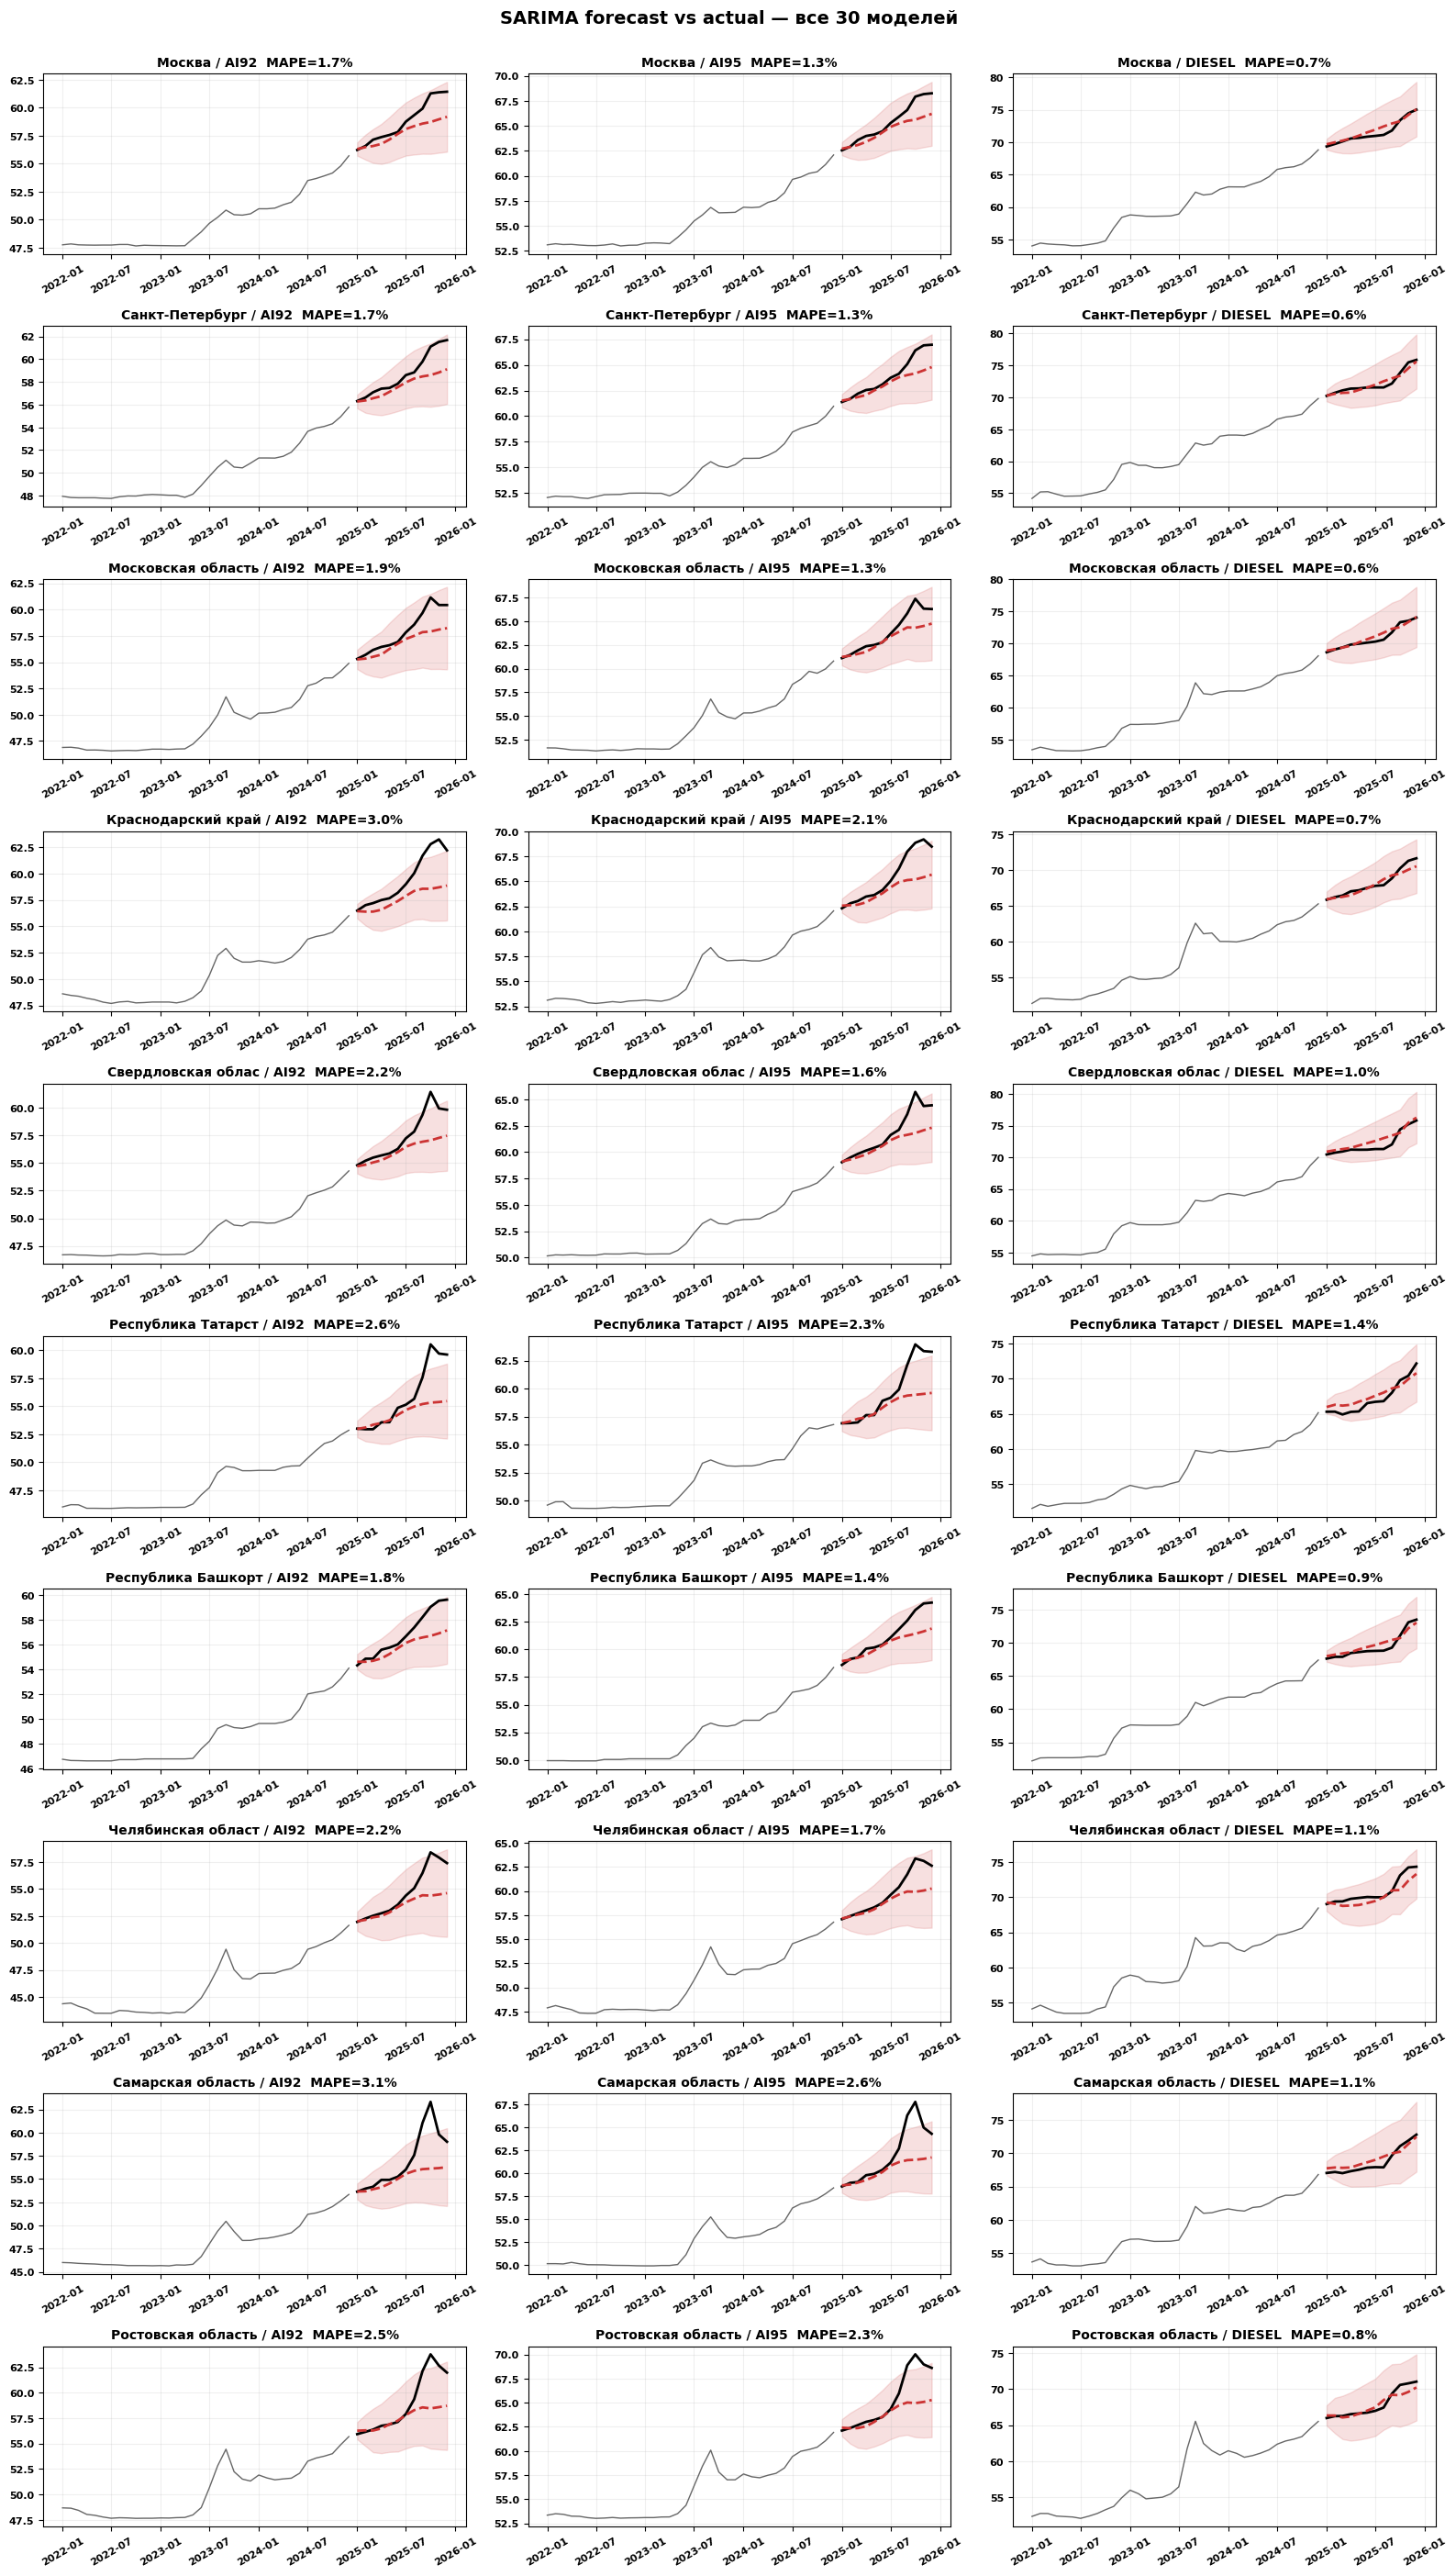

In [3]:
fig, axs = plt.subplots(10, 3, figsize=(16, 28), sharey=False)
fuel_order = ["ai92", "ai95", "diesel"]
regions_in_order = reg["region_id"].drop_duplicates().tolist()

for i, rid in enumerate(regions_in_order):
    rname = reg.loc[reg["region_id"] == rid, "region_name"].iloc[0]
    for j, ft in enumerate(fuel_order):
        ax = axs[i, j]
        try:
            art = load_artifact(rid, ft)
            row = reg[(reg["region_id"] == rid) & (reg["fuel_type"] == ft)].iloc[0]
            series = load_series(rid, ft)
            train, test = series[:-12], series[-12:]
            fc = art["model"].get_forecast(steps=12)
            yhat = fc.predicted_mean
            yhat.index = test.index
            ci = fc.conf_int(alpha=0.05); ci.index = test.index

            ax.plot(train.index[-36:], train.values[-36:], color="#666", lw=1)
            ax.plot(test.index, test.values, color="black", lw=2)
            ax.plot(yhat.index, yhat.values, color="#c33", lw=2, linestyle="--")
            ax.fill_between(yhat.index, ci.iloc[:, 0], ci.iloc[:, 1], color="#c33", alpha=0.15)
            ax.set_title(f"{rname[:18]} / {ft.upper()}  MAPE={row['train_mape_pct']:.1f}%", fontsize=10)
            ax.tick_params(axis="x", rotation=30, labelsize=8)
            ax.tick_params(axis="y", labelsize=8)
            ax.grid(alpha=0.2)
        except Exception as e:
            ax.text(0.5, 0.5, f"FAIL\n{e}", ha="center", va="center", transform=ax.transAxes, color="red")

plt.suptitle("SARIMA forecast vs actual — все 30 моделей", y=1.001, fontsize=14)
plt.tight_layout()
plt.show()

## 2. 5-летний прогноз: устойчивость на длинном горизонте

SARIMA должна давать монотонно растущий прогноз (CPI > 0); сезонные колебания не должны превышать 2–3 % уровня; ширина 95 % CI не должна превышать ~30 % прогнозируемой цены.


  Москва               / ai95  : 5y growth =  22.7%,  CI width @ end =  22.1% of forecast
  Москва               / diesel: 5y growth =  38.7%,  CI width @ end =  21.3% of forecast
  Санкт-Петербург      / ai95  : 5y growth =  20.7%,  CI width @ end =  20.7% of forecast
  Санкт-Петербург      / diesel: 5y growth =  36.1%,  CI width @ end =  24.3% of forecast


  Московская область   / ai95  : 5y growth =  23.6%,  CI width @ end =  27.6% of forecast
  Московская область   / diesel: 5y growth =  38.6%,  CI width @ end =  23.7% of forecast


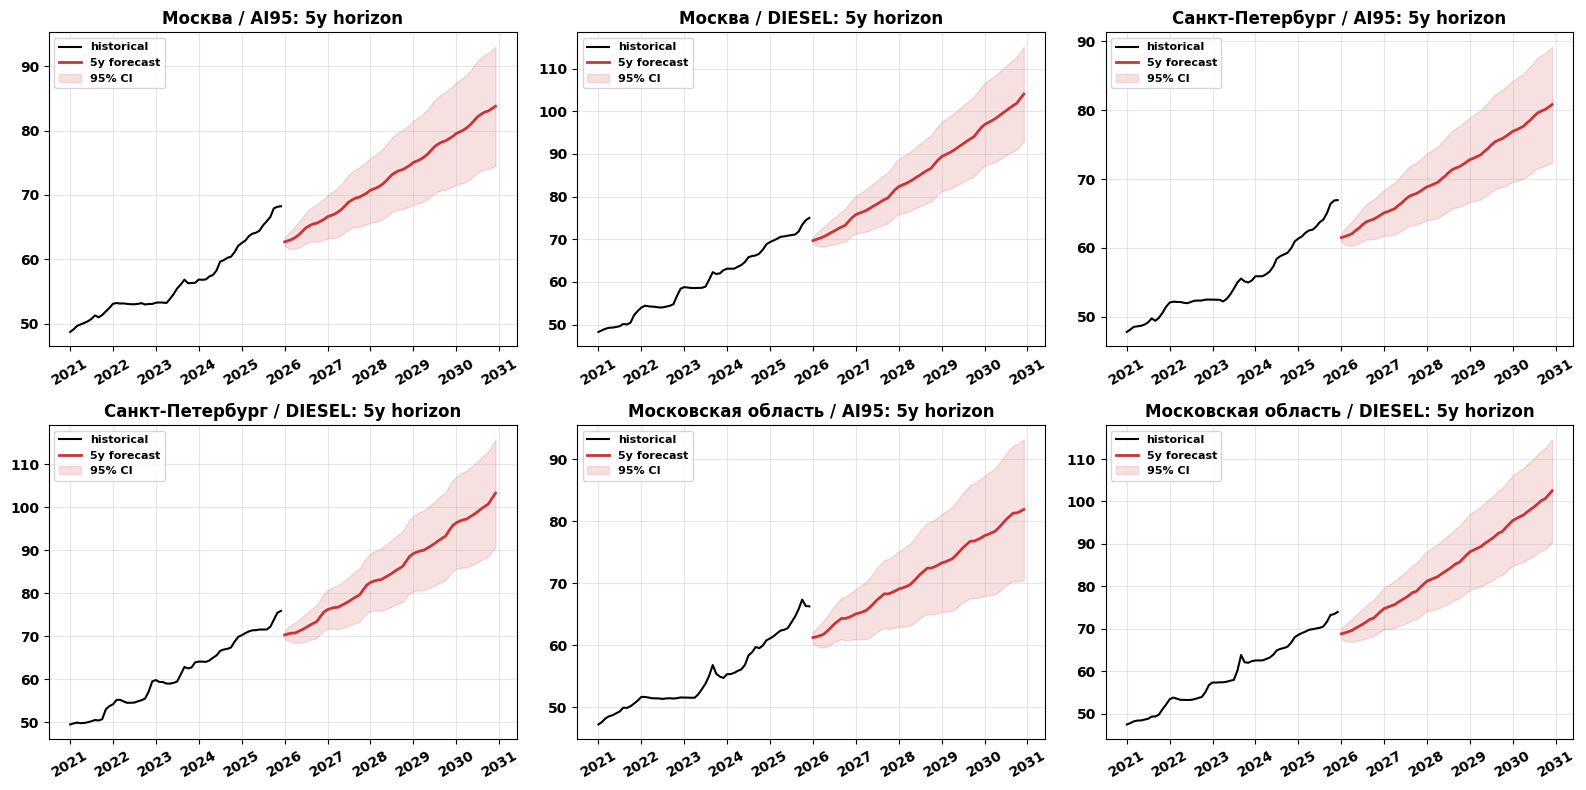

In [4]:
fig, axs = plt.subplots(2, 3, figsize=(16, 8))

# 6 опорных серий: Москва, СПб, Мособл × ai95, diesel
sample = [(1, "ai95"), (1, "diesel"), (19, "ai95"), (19, "diesel"), (2, "ai95"), (2, "diesel")]
horizon_months = 60

for ax, (rid, ft) in zip(axs.flatten(), sample):
    rname = reg.loc[reg["region_id"] == rid, "region_name"].iloc[0]
    art = load_artifact(rid, ft)
    series = load_series(rid, ft)
    fc = art["model"].get_forecast(steps=horizon_months)
    yhat = fc.predicted_mean
    last_train_idx = series.index[-1]
    future_idx = pd.date_range(last_train_idx + pd.offsets.MonthBegin(1), periods=horizon_months, freq="MS")
    yhat.index = future_idx
    ci = fc.conf_int(alpha=0.05); ci.index = future_idx

    ax.plot(series.index[-60:], series.values[-60:], color="black", lw=1.5, label="historical")
    ax.plot(yhat.index, yhat.values, color="#c33", lw=2, label="5y forecast")
    ax.fill_between(yhat.index, ci.iloc[:, 0], ci.iloc[:, 1], color="#c33", alpha=0.15, label="95% CI")
    ax.set_title(f"{rname[:18]} / {ft.upper()}: 5y horizon")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    ax.tick_params(axis="x", rotation=30)

    growth_5y = (yhat.iloc[-1] / series.iloc[-1] - 1) * 100
    ci_width_pct = (ci.iloc[-1, 1] - ci.iloc[-1, 0]) / yhat.iloc[-1] * 100
    print(f"  {rname[:20]:20} / {ft:6}: 5y growth = {growth_5y:5.1f}%,  CI width @ end = {ci_width_pct:5.1f}% of forecast")

plt.tight_layout()
plt.show()

**Что мы хотим увидеть:**

- Прогноз монотонно растёт (~ +30…+50 % за 5 лет, что согласуется с инфляцией 6–8 % CAGR).
- 95 % CI расширяется к концу горизонта, но < 30 % самого прогноза — модель «знает свою неопределённость».
- ДТ растёт чуть быстрее AI-95 (исторический паттерн 2022-2025).


## 3. Cross-region sanity: соседние регионы должны быть скоррелированы

Корреляция прогнозов AI-95 в Москве и СПб исторически > 0.99. Если SARIMA не «сошёл с ума», эта корреляция сохраняется на прогнозном горизонте.


In [5]:
def get_5y_forecast(rid: int, ft: str) -> np.ndarray:
    art = load_artifact(rid, ft)
    return art["model"].get_forecast(steps=60).predicted_mean.values


pairs = [
    (1, 19, "ai95", "Москва", "СПб"),
    (1, 2, "ai95", "Москва", "Мособласть"),
    (19, 33, "ai95", "СПб", "Краснодар"),
    (1, 60, "ai95", "Москва", "Свердловская"),
    (1, 19, "diesel", "Москва", "СПб (ДТ)"),
]

print(f"{'pair':40}  {'fuel':6}  {'corr (5y)':>10}  {'min_diff_%':>11}  {'max_diff_%':>11}")
print("-" * 90)
for r1, r2, ft, n1, n2 in pairs:
    f1 = get_5y_forecast(r1, ft)
    f2 = get_5y_forecast(r2, ft)
    corr = np.corrcoef(f1, f2)[0, 1]
    diff_pct = (f1 / f2 - 1) * 100
    print(f"{f'{n1} <-> {n2}':40}  {ft:6}  {corr:>10.4f}  {diff_pct.min():>10.2f}%  {diff_pct.max():>10.2f}%")

pair                                      fuel     corr (5y)   min_diff_%   max_diff_%
------------------------------------------------------------------------------------------
Москва <-> СПб                            ai95        0.9999        1.96%        3.75%
Москва <-> Мособласть                     ai95        0.9997        1.81%        2.66%


СПб <-> Краснодар                         ai95        0.9998       -1.74%       -1.10%
Москва <-> Свердловская                   ai95        1.0000        6.01%        7.19%
Москва <-> СПб (ДТ)                       diesel      0.9998       -0.84%        1.22%


**Что мы хотим увидеть:** все корреляции > 0.95 (в идеале > 0.99). Различия в уровне < ±10 % (в РФ цены отличаются между Москвой и Свердловской до 8–10 %, что отражает региональную премию).

## 4. Cross-fuel sanity: AI-92 < AI-95 в каждом регионе

Это базовая физика рынка топлива: AI-95 всегда дороже AI-92 (примерно на 1.5–2 ₽/л). Если в каком-то регионе прогноз перевернёт это неравенство — это серьёзный bug.


In [6]:
print(f"{'region':25}  {'last_actual':>13}  {'5y_forecast (last month)':>26}")
print(f"{'':25}  {'92    95   ДТ ':>13}  {'    92      95     ДТ':>26}")
print("-" * 90)
inversions = 0
for rid in reg["region_id"].drop_duplicates():
    rname = reg.loc[reg["region_id"] == rid, "region_name"].iloc[0]
    last_92 = load_series(rid, "ai92").iloc[-1]
    last_95 = load_series(rid, "ai95").iloc[-1]
    last_dt = load_series(rid, "diesel").iloc[-1]
    f5_92 = get_5y_forecast(rid, "ai92")[-1]
    f5_95 = get_5y_forecast(rid, "ai95")[-1]
    f5_dt = get_5y_forecast(rid, "diesel")[-1]
    inv = "INV!" if f5_92 >= f5_95 else "    "
    if f5_92 >= f5_95:
        inversions += 1
    print(f"{rname[:25]:25}  {last_92:5.1f} {last_95:5.1f} {last_dt:5.1f}  "
          f"{f5_92:6.1f}  {f5_95:6.1f}  {f5_dt:6.1f}  {inv}")

print()
print(f"Inversions (AI-92 >= AI-95 на горизонте 5y): {inversions}/10")
print("(должно быть 0)")

region                       last_actual    5y_forecast (last month)
                           92    95   ДТ            92      95     ДТ
------------------------------------------------------------------------------------------


Москва                      61.4  68.2  75.0    73.8    83.8   104.0      


Санкт-Петербург             61.7  67.0  75.9    73.0    80.9   103.2      


Московская область          60.4  66.3  74.0    72.6    81.9   102.5      


Краснодарский край          62.2  68.5  71.6    71.5    81.8    96.6      


Свердловская область        59.8  64.4  75.8    70.8    78.2   105.0      
Республика Татарстан        59.6  63.3  72.2    66.2    71.7    96.4      


Республика Башкортостан     59.6  64.2  73.5    70.6    77.0    99.8      
Челябинская область         57.4  62.6  74.3    67.0    75.3    97.5      


Самарская область           59.0  64.3  72.8    68.2    75.6    98.1      
Ростовская область          62.0  68.6  71.0    70.7    80.1    93.4      

Inversions (AI-92 >= AI-95 на горизонте 5y): 0/10
(должно быть 0)


## 5. Итоги валидации

| Чек | Цель |
|---|---|
| Forecast vs actual для 30 моделей | визуально согласован |
| 5y growth | 25–50 % |
| 5y CI width | < 30 % |
| Cross-region corr (AI-95) | > 0.95 |
| AI-92 < AI-95 на 5y horizon | 0 инверсий |
